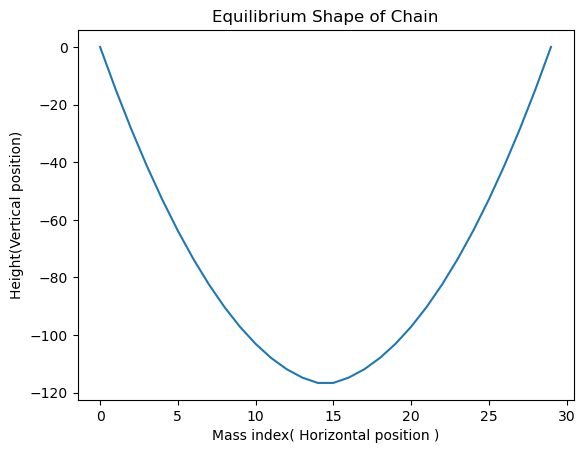

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

N = 30
k = 10
l0 = 1
m = 1
g = 9.8

x = np.arange(N)

# endpoints fixed
y0 = 0
yN = 0

y_initial = np.zeros(N-2)

def energy(y):

    y = np.concatenate(([y0], y, [yN]))

    spring_energy = 0
    for j in range(N-1):
        dy = y[j+1] - y[j]
        length = np.sqrt(1 + dy**2)
        spring_energy += 0.5*k*(length-l0)**2

    grav_energy = np.sum(m*g*y)

    return spring_energy + grav_energy


res = minimize(energy, y_initial)

y_opt = np.concatenate(([y0], res.x, [yN]))

plt.plot(x, y_opt,)
plt.xlabel("Mass index( Horizontal position )")
plt.ylabel("Height(Vertical position)")
plt.title("Equilibrium Shape of Chain")
plt.show()

## Objective
To determine the equilibrium shape of a chain suspended between two fixed endpoints by minimizing its total energy, and compare the numerical result with the analytical catenary solution.

---

## Discrete Model

We model the chain as $N$ point masses connected by springs.

Let the vertical positions be:
$$
y_0, y_1, y_2, \dots, y_{N-1}
$$

The endpoints are fixed:
$$
y_0 = 0, \quad y_{N-1} = 0
$$

---

## Energy of the System

### Spring Energy

The length of each segment is:
$$
\ell_j = \sqrt{1 + (y_{j+1} - y_j)^2}
$$

The spring energy is:
$$
E_{\text{spring}} = \sum_{j=0}^{N-2} \frac{k}{2}(\ell_j - \ell_0)^2
$$

---

### Gravitational Energy

$$
E_{\text{grav}} = \sum_{j=0}^{N-1} m g y_j
$$

---

### Total Energy

$$
E = E_{\text{spring}} + E_{\text{grav}}
$$

## Numerical Method

We minimize the total energy using:
$$
\texttt{scipy.optimize.minimize}
$$

The optimizer adjusts the intermediate heights $y_1, \dots, y_{N-2}$ to find the configuration of minimum energy.

---